In [1]:
%pip install -q kaggle pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

OUTPUT_DIR = Path(r"C:\Users\mribl\Documents\GitHub\College\Sem 7\Advance Predictive Analysis\Lab\DA 4\Output")
DATA_DIR = Path('data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print('Output folder:', OUTPUT_DIR.resolve())
print('Data folder:', DATA_DIR.resolve())

Output folder: C:\Users\mribl\Documents\GitHub\College\Sem 7\Advance Predictive Analysis\Lab\DA 4\Output
Data folder: C:\Users\mribl\data


In [3]:
KAGGLE_DATASET = 'vjchoudhary7/customer-segmentation-tutorial-in-python'
PREFERRED_TARGET = None

zip_path = DATA_DIR / 'kaggle_dataset.zip'
download_cmd = f'kaggle datasets download -d {KAGGLE_DATASET} -p {DATA_DIR.as_posix()} --force'
status = os.system(download_cmd)
if status != 0:
    raise RuntimeError('Kaggle download failed. Check Kaggle API credentials and dataset slug.')

if not zip_path.exists():
    zips = sorted(DATA_DIR.glob('*.zip'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not zips:
        raise FileNotFoundError('Downloaded ZIP not found in data folder.')
    zip_path = zips[0]

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(DATA_DIR)

print('Downloaded and extracted:', zip_path.name)
print('Extracted files:')
for p in DATA_DIR.glob('*'):
    print('-', p.name)

Downloaded and extracted: customer-segmentation-tutorial-in-python.zip
Extracted files:
- business_email_intent.csv
- customer-segmentation-tutorial-in-python.zip
- enron_spam.csv
- Mall_Customers.csv
- spamassassin.csv
- uci_spam.csv


In [4]:
csv_files = sorted(DATA_DIR.glob('*.csv'))
if not csv_files:
    raise FileNotFoundError('No CSV files found after extraction. Update loading logic if dataset uses a different format.')

df = pd.read_csv(csv_files[0])
print('Loaded file:', csv_files[0].name)
print('Shape:', df.shape)
display(df.head())

Loaded file: business_email_intent.csv
Shape: (220, 4)


,email_id,subject,body,label
0,D1_0001,Please provide,Please provide the latest quarter financial re...,request
1,D1_0002,Can you,Can you send me access permissions for the rep...,request
2,D1_0003,Requesting approval,Requesting approval for budget allocation.,request
3,D1_0004,Please provide,Please provide the latest quarter financial re...,request
4,D1_0005,Can you,Can you send me access permissions for the rep...,request


In [5]:
def infer_target_column(frame: pd.DataFrame, preferred=None):
    if preferred and preferred in frame.columns:
        return preferred

    candidate_names = [
        'segment', 'customer_segment', 'segment_label', 'class', 'label', 'target',
        'cluster', 'persona', 'group'
    ]
    cols_lower = {c.lower(): c for c in frame.columns}
    for name in candidate_names:
        if name in cols_lower:
            return cols_lower[name]

    obj_cols = frame.select_dtypes(include=['object', 'category']).columns.tolist()
    if obj_cols:
        cardinalities = {c: frame[c].nunique(dropna=True) for c in obj_cols}
        valid = {k: v for k, v in cardinalities.items() if 2 <= v <= max(20, int(0.2 * len(frame)))}
        if valid:
            return sorted(valid.items(), key=lambda x: x[1])[0][0]

    raise ValueError('Unable to infer target column. Set PREFERRED_TARGET manually.')

TARGET_COLUMN = infer_target_column(df, PREFERRED_TARGET)

id_like_cols = [c for c in df.columns if 'id' in c.lower() and c != TARGET_COLUMN]
duplicate_count = int(df.duplicated().sum())
missing_summary = df.isna().sum().sort_values(ascending=False)

print('Target column:', TARGET_COLUMN)
print('Possible identifier columns (excluded from modeling):', id_like_cols)
print('Duplicate rows:', duplicate_count)
display(missing_summary[missing_summary > 0].to_frame('missing_count'))

Target column: label
Possible identifier columns (excluded from modeling): ['email_id']
Duplicate rows: 0


,missing_count


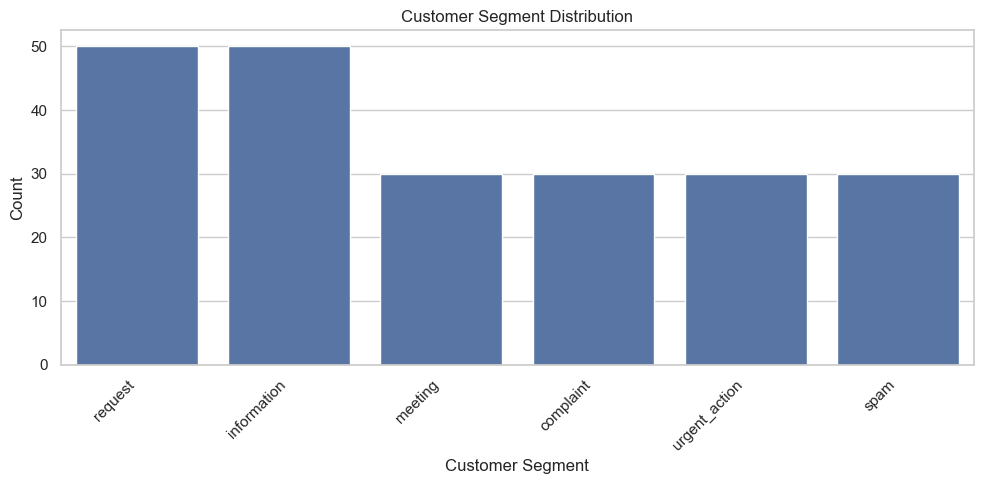

No meaningful missingness detected; skipping missing value chart.


In [6]:
segment_counts = df[TARGET_COLUMN].value_counts(dropna=False)
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x=TARGET_COLUMN, order=segment_counts.index)
ax.set_title('Customer Segment Distribution')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_customer_segment_distribution.png', dpi=200)
plt.show()

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
meaningful_missing = missing_pct[missing_pct > 0]
if len(meaningful_missing) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=meaningful_missing.index, y=meaningful_missing.values, color='#d95f02')
    plt.title('Missing Value Percentage by Feature')
    plt.xlabel('Feature')
    plt.ylabel('Missing %')
    plt.xticks(rotation=75, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '02_missing_values.png', dpi=200)
    plt.show()
else:
    print('No meaningful missingness detected; skipping missing value chart.')

Numeric features: []
Categorical features: ['subject', 'body']


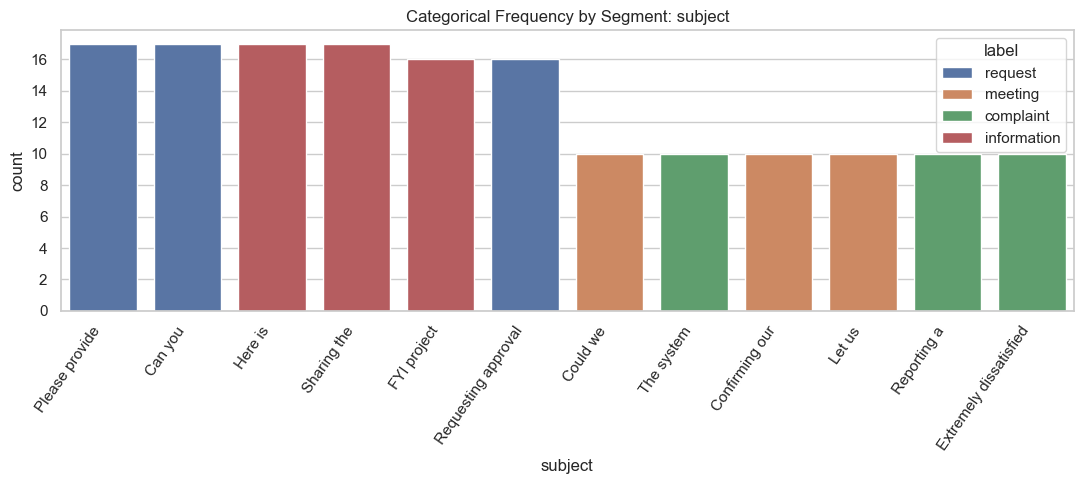

In [7]:
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols_all if c != TARGET_COLUMN and c not in id_like_cols]
categorical_cols = [c for c in df.columns if c not in numeric_cols and c != TARGET_COLUMN and c not in id_like_cols]

print('Numeric features:', numeric_cols)
print('Categorical features:', categorical_cols)

if numeric_cols:
    feature_for_dist = numeric_cols[0]
    plt.figure(figsize=(9, 5))
    sns.histplot(df[feature_for_dist], kde=True, bins=30, color='#1b9e77')
    plt.title(f'Numerical Distribution: {feature_for_dist}')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '03_numerical_distribution.png', dpi=200)
    plt.show()

if numeric_cols:
    compare_feature = numeric_cols[min(1, len(numeric_cols)-1)]
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=TARGET_COLUMN, y=compare_feature)
    plt.title(f'Segment Comparison by {compare_feature}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '04_segment_comparison.png', dpi=200)
    plt.show()

if categorical_cols:
    cat_feature = categorical_cols[0]
    plt.figure(figsize=(11, 5))
    top_cats = df[cat_feature].astype(str).value_counts().head(12).index
    plot_df = df[df[cat_feature].astype(str).isin(top_cats)].copy()
    sns.countplot(data=plot_df, x=cat_feature, hue=TARGET_COLUMN, order=top_cats)
    plt.title(f'Categorical Frequency by Segment: {cat_feature}')
    plt.xticks(rotation=55, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '04b_categorical_relationship.png', dpi=200)
    plt.show()

In [8]:
df_model = df.copy()
drop_cols = [c for c in id_like_cols if c in df_model.columns]
df_model = df_model.drop(columns=drop_cols, errors='ignore')

X = df_model.drop(columns=[TARGET_COLUMN])
y = df_model[TARGET_COLUMN].astype(str)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)
print('Train class distribution:')
display(y_train.value_counts(normalize=True).rename('proportion').to_frame())

Training shape: (176, 2)
Testing shape: (44, 2)
Train class distribution:


,proportion
label,
information,0.227273
request,0.227273
complaint,0.136364
spam,0.136364
urgent_action,0.136364
meeting,0.136364


In [9]:
gaussian_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
    ],
    sparse_threshold=0
)

bernoulli_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('kbins', KBinsDiscretizer(n_bins=2, encode='onehot-dense', strategy='quantile'))
        ]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
    ],
    sparse_threshold=0
)

categorical_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('kbins', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'))
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=999999))
        ]), cat_cols),
    ]
)

models = {
    'DummyClassifier': Pipeline([('model', DummyClassifier(strategy='most_frequent'))]),
    'GaussianNB': Pipeline([('prep', gaussian_preprocessor), ('model', GaussianNB())]),
    'BernoulliNB': Pipeline([('prep', bernoulli_preprocessor), ('model', BernoulliNB())]),
    'CategoricalNB': Pipeline([('prep', categorical_preprocessor), ('model', CategoricalNB(alpha=1.0))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

cv_rows = []
cv_fold_macro_f1 = {}

for model_name, model in models.items():
    cv_result = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    fold_scores = cv_result['test_f1_macro']
    cv_fold_macro_f1[model_name] = fold_scores
    cv_rows.append({
        'Model': model_name,
        'Accuracy (CV Mean)': np.mean(cv_result['test_accuracy']),
        'Precision Macro (CV Mean)': np.mean(cv_result['test_precision_macro']),
        'Recall Macro (CV Mean)': np.mean(cv_result['test_recall_macro']),
        'F1 Macro (CV Mean)': np.mean(cv_result['test_f1_macro']),
        'F1 Macro (CV Std)': np.std(cv_result['test_f1_macro']),
        'F1 Weighted (CV Mean)': np.mean(cv_result['test_f1_weighted'])
    })

cv_summary = pd.DataFrame(cv_rows).sort_values('F1 Macro (CV Mean)', ascending=False).reset_index(drop=True)
display(cv_summary)

fold_table = pd.DataFrame({k: pd.Series(v) for k, v in cv_fold_macro_f1.items()})
fold_table.index = [f'Fold_{i}' for i in range(1, 6)]
display(fold_table)

,Model,Accuracy (CV Mean),Precision Macro (CV Mean),Recall Macro (CV Mean),F1 Macro (CV Mean),F1 Macro (CV Std),F1 Weighted (CV Mean)
0,GaussianNB,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
1,BernoulliNB,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
2,CategoricalNB,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
3,DummyClassifier,0.227302,0.037884,0.166667,0.061734,0.000564,0.084201


,DummyClassifier,GaussianNB,BernoulliNB,CategoricalNB
Fold_1,0.060606,1.0,1.0,1.0
Fold_2,0.062016,1.0,1.0,1.0
Fold_3,0.062016,1.0,1.0,1.0
Fold_4,0.062016,1.0,1.0,1.0
Fold_5,0.062016,1.0,1.0,1.0


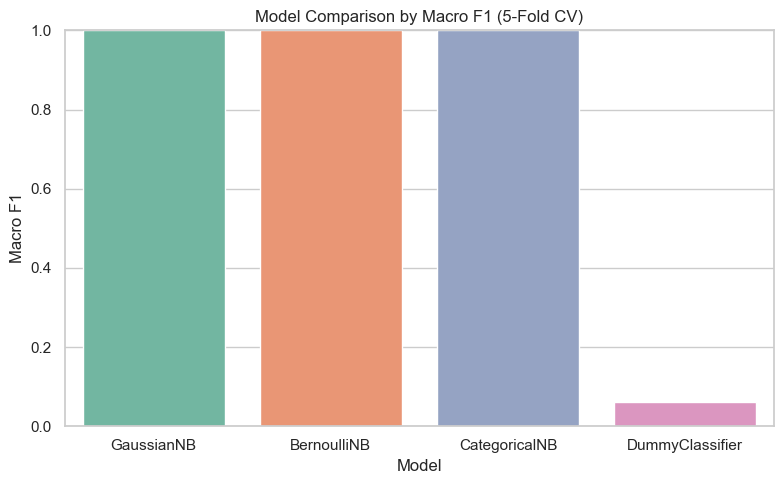

Selected final model: GaussianNB


In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cv_summary, x='Model', y='F1 Macro (CV Mean)', palette='Set2')
plt.title('Model Comparison by Macro F1 (5-Fold CV)')
plt.xlabel('Model')
plt.ylabel('Macro F1')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_model_macro_f1_comparison.png', dpi=200)
plt.show()

best_model_name = cv_summary.iloc[0]['Model']
best_model = models[best_model_name]
print('Selected final model:', best_model_name)

Demographic                   
Psychographic    subject, body
Behavioral       subject, body
Name: Features, dtype: object

,Feature Group,Macro F1 (CV Mean),Macro F1 (CV Std),Feature Count
0,Psychographic Only,1.0,0.0,2
1,Behavioral Only,1.0,0.0,2
2,All Features,1.0,0.0,2


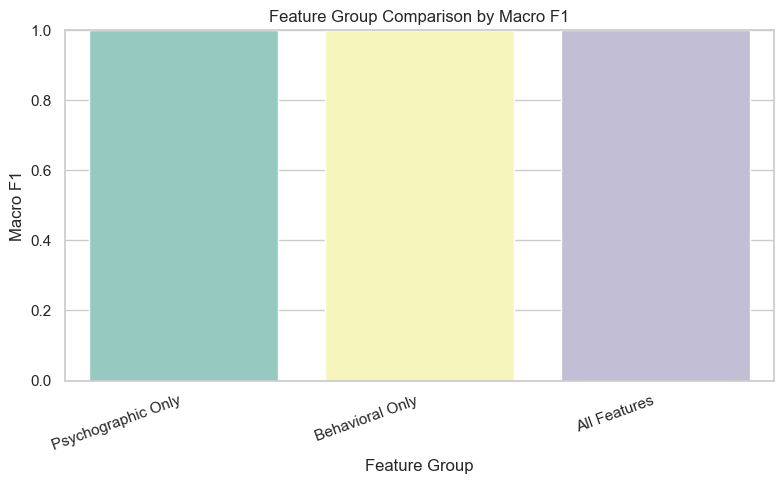

In [11]:
def split_feature_groups(columns):
    demo_keys = ['age', 'gender', 'sex', 'income', 'salary', 'education', 'occupation', 'job', 'marital', 'family', 'children', 'city', 'state', 'country']
    psycho_keys = ['lifestyle', 'interest', 'attitude', 'personality', 'value', 'opinion', 'hobby', 'preference', 'psychographic']
    behav_keys = ['purchase', 'spend', 'spending', 'frequency', 'recency', 'tenure', 'campaign', 'response', 'discount', 'transaction', 'visit', 'click', 'engagement', 'usage']

    groups = {'Demographic': [], 'Psychographic': [], 'Behavioral': []}
    for c in columns:
        cl = c.lower()
        if any(k in cl for k in demo_keys):
            groups['Demographic'].append(c)
        elif any(k in cl for k in psycho_keys):
            groups['Psychographic'].append(c)
        elif any(k in cl for k in behav_keys):
            groups['Behavioral'].append(c)

    if not groups['Demographic']:
        groups['Demographic'] = [c for c in columns if c in num_cols][:max(1, min(3, len(num_cols)))]
    if not groups['Psychographic']:
        leftovers = [c for c in columns if c not in groups['Demographic']]
        groups['Psychographic'] = leftovers[:max(1, min(3, len(leftovers)))]
    if not groups['Behavioral']:
        leftovers = [c for c in columns if c not in groups['Demographic'] + groups['Psychographic']]
        groups['Behavioral'] = leftovers if leftovers else columns[:max(1, min(3, len(columns)))]

    return groups

feature_groups = split_feature_groups(X.columns.tolist())
display(pd.Series({k: ', '.join(v) for k, v in feature_groups.items()}, name='Features'))

group_sets = {
    'Demographic Only': feature_groups['Demographic'],
    'Psychographic Only': feature_groups['Psychographic'],
    'Behavioral Only': feature_groups['Behavioral'],
    'All Features': X.columns.tolist()
}

group_rows = []
for group_name, group_cols in group_sets.items():
    group_cols = [c for c in group_cols if c in X.columns]
    if len(group_cols) == 0:
        continue
    score = cross_validate(best_model, X_train[group_cols], y_train, cv=cv, scoring='f1_macro', n_jobs=-1)['test_score']
    group_rows.append({
        'Feature Group': group_name,
        'Macro F1 (CV Mean)': np.mean(score),
        'Macro F1 (CV Std)': np.std(score),
        'Feature Count': len(group_cols)
    })

group_summary = pd.DataFrame(group_rows).sort_values('Macro F1 (CV Mean)', ascending=False)
display(group_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=group_summary, x='Feature Group', y='Macro F1 (CV Mean)', palette='Set3')
plt.title('Feature Group Comparison by Macro F1')
plt.xlabel('Feature Group')
plt.ylabel('Macro F1')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_feature_group_macro_f1_comparison.png', dpi=200)
plt.show()

,Test Score
Accuracy,1.0
Macro Precision,1.0
Macro Recall,1.0
Macro F1,1.0
Weighted F1,1.0


Confusion Matrix Labels (Actual x Predicted):
['complaint', 'information', 'meeting', 'request', 'spam', 'urgent_action']

Confusion Matrix (Count):
               complaint  information  meeting  request  spam  urgent_action
complaint              6            0        0        0     0              0
information            0           10        0        0     0              0
meeting                0            0        6        0     0              0
request                0            0        0       10     0              0
spam                   0            0        0        0     6              0
urgent_action          0            0        0        0     0              6

Confusion Matrix (Row Normalized):
               complaint  information  meeting  request  spam  urgent_action
complaint            1.0          0.0      0.0      0.0   0.0            0.0
information          0.0          1.0      0.0      0.0   0.0            0.0
meeting              0.0          0.0      1.

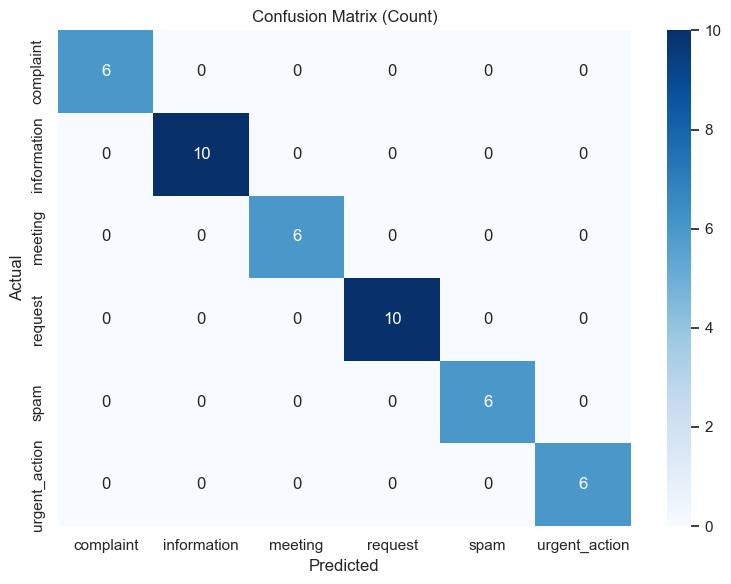

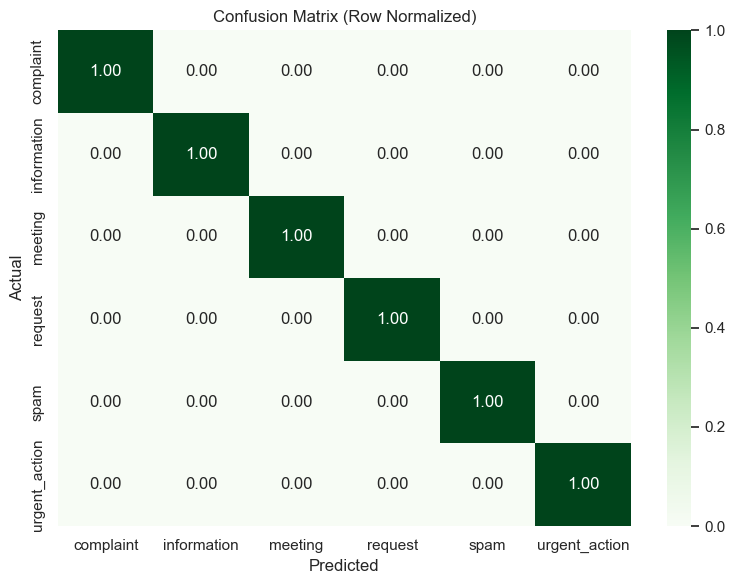

,precision,recall,f1-score,support
complaint,1.0,1.0,1.0,6.0
information,1.0,1.0,1.0,10.0
meeting,1.0,1.0,1.0,6.0
request,1.0,1.0,1.0,10.0
spam,1.0,1.0,1.0,6.0
urgent_action,1.0,1.0,1.0,6.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,44.0
weighted avg,1.0,1.0,1.0,44.0


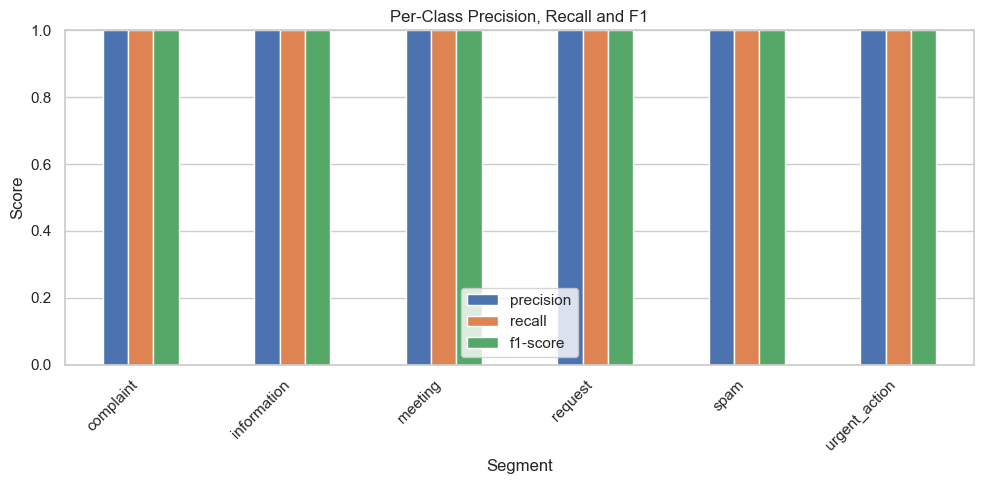

In [12]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test) if hasattr(best_model, 'predict_proba') else None

test_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Macro Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
    'Macro Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
    'Macro F1': f1_score(y_test, y_pred, average='macro', zero_division=0),
    'Weighted F1': f1_score(y_test, y_pred, average='weighted', zero_division=0)
}
display(pd.Series(test_metrics, name='Test Score').to_frame())

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')

print('Confusion Matrix Labels (Actual x Predicted):')
print(labels)
print('\nConfusion Matrix (Count):')
print(pd.DataFrame(cm, index=labels, columns=labels))
print('\nConfusion Matrix (Row Normalized):')
print(pd.DataFrame(cm_norm, index=labels, columns=labels).round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (Count)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_confusion_matrix_count.png', dpi=200)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (Row Normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07b_confusion_matrix_row_normalized.png', dpi=200)
plt.show()

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
display(report_df)

class_rows = report_df.loc[[c for c in report_df.index if c not in ['accuracy', 'macro avg', 'weighted avg']]].copy()
class_rows[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 5))
plt.title('Per-Class Precision, Recall and F1')
plt.xlabel('Segment')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07c_per_class_metrics.png', dpi=200)
plt.show()

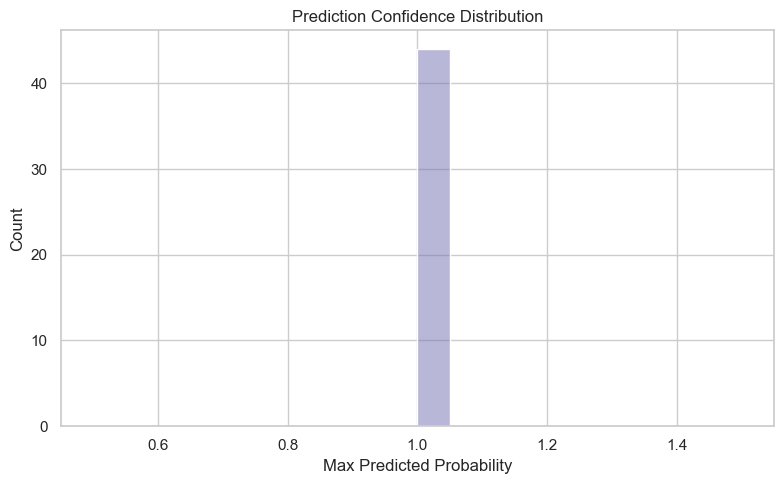

No misclassifications found on test set.


In [13]:
if y_proba is not None:
    confidence = y_proba.max(axis=1)
    plt.figure(figsize=(8, 5))
    sns.histplot(confidence, bins=20, kde=True, color='#7570b3')
    plt.title('Prediction Confidence Distribution')
    plt.xlabel('Max Predicted Probability')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '08_confidence_distribution.png', dpi=200)
    plt.show()

    error_df = X_test.copy()
    error_df['Actual'] = y_test.values
    error_df['Predicted'] = y_pred
    error_df['Confidence'] = confidence
    error_df = error_df[error_df['Actual'] != error_df['Predicted']].sort_values('Confidence', ascending=False)

    top_errors = error_df.head(5).copy()
    if len(top_errors) > 0:
        top_errors['Possible_Reason'] = np.where(top_errors['Confidence'] < 0.6, 'Low confidence boundary case', 'High-confidence confusion between similar segments')
        display(top_errors[['Actual', 'Predicted', 'Confidence', 'Possible_Reason'] + [c for c in top_errors.columns if c not in ['Actual', 'Predicted', 'Confidence', 'Possible_Reason']][:5]])
        top_errors.to_csv(OUTPUT_DIR / 'top_5_errors.csv', index=False)
    else:
        print('No misclassifications found on test set.')
else:
    print('Selected model does not support predict_proba; confidence analysis skipped.')

In [14]:
sample_customer = X_test.iloc[[0]].copy()
sample_pred = best_model.predict(sample_customer)[0]
print('Predicted Segment:', sample_pred)

if hasattr(best_model, 'predict_proba'):
    prob = best_model.predict_proba(sample_customer)[0]
    labels_model = best_model.classes_
    prob_df = pd.DataFrame({'Segment': labels_model, 'Probability': prob}).sort_values('Probability', ascending=False)
    display(prob_df)

    confidence_val = float(prob.max())
    threshold = 0.60
    recommendation = 'Manual review recommended' if confidence_val < threshold else 'Automatic segmentation acceptable with monitoring'
    print('Confidence:', round(confidence_val, 4))
    print('Recommendation:', recommendation)

Predicted Segment: spam


,Segment,Probability
4,spam,1.0
0,complaint,0.0
1,information,0.0
2,meeting,0.0
3,request,0.0
5,urgent_action,0.0


Confidence: 1.0
Recommendation: Automatic segmentation acceptable with monitoring


In [15]:
generated = sorted([p.name for p in OUTPUT_DIR.glob('*')])
print('Generated output files:')
for f in generated:
    print('-', f)

Generated output files:
- 01_customer_segment_distribution.png
- 04b_categorical_relationship.png
- 05_model_macro_f1_comparison.png
- 06_feature_group_macro_f1_comparison.png
- 07_confusion_matrix_count.png
- 07b_confusion_matrix_row_normalized.png
- 07c_per_class_metrics.png
- 08_confidence_distribution.png
